LifeLine Hospital Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Pandas Version: 3.0.5
NumPy Version: 2.5.1
Libraries imported successfully!


In [2]:
df = pd.read_csv(r"C:\Users\ravan\OneDrive\Desktop\DATA ANALYSIS PROJECT\LIFELINE HOAPITAL ANALYSIS\Dataset\LIFELINE_Hospital_Dataset.csv")

In [3]:
df.head()

,Patient_ID,Admit_Date,Discharge_Date,Diagnosis,Bed_Occupancy,Test,Doctor_Name,Followup_Date,Feedback,Billing_Amount,Health_Insurance_Amount,Total_Amount_Payable
0,33021,02-05-2026,03-05-2026,Thyroid Disorder,Semi Private,"Blood Test, Thyroid Profile",Dr. Sandeep Kapoor (General Medicine),NaN,Good,"₹10,810","₹7,820","₹2,990"
1,2276,25-03-2026,31-03-2026,Kidney Stones,Private Room,"CT Scan, Kidney Function Test",Dr. Shweta Menon (Nephrology),28-04-2026,Needs Improvement,"₹111,610","₹67,910","₹43,700"
2,8331,29-07-2026,07-08-2026,Kidney Stones,Emergency Observation,Kidney Function Test,Dr. Divya Mishra (Nephrology),19-08-2026,Satisfied,"₹44,180","₹39,620","₹4,560"
3,24788,16-02-2026,18-02-2026,Pneumonia,Semi Private,"CBC, X-Ray",Dr. Sunita Tiwari (Pulmonology),NaN,Excellent,"₹18,870","₹10,900","₹7,970"
4,21153,12-12-2025,14-12-2025,Anxiety Disorder,Private Room,Blood Test,Dr. Anjali Menon (General Medicine),28-12-2025,Poor,"₹30,110","₹19,680","₹10,430"


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8000
Columns: 12


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Patient_ID               8000 non-null   int64
 1   Admit_Date               8000 non-null   str  
 2   Discharge_Date           8000 non-null   str  
 3   Diagnosis                8000 non-null   str  
 4   Bed_Occupancy            8000 non-null   str  
 5   Test                     8000 non-null   str  
 6   Doctor_Name              8000 non-null   str  
 7   Followup_Date            6927 non-null   str  
 8   Feedback                 8000 non-null   str  
 9   Billing_Amount           8000 non-null   str  
 10  Health_Insurance_Amount  8000 non-null   str  
 11  Total_Amount_Payable     8000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 750.1 KB


In [6]:
df.isnull().sum()

Patient_ID                    0
Admit_Date                    0
Discharge_Date                0
Diagnosis                     0
Bed_Occupancy                 0
Test                          0
Doctor_Name                   0
Followup_Date              1073
Feedback                      0
Billing_Amount                0
Health_Insurance_Amount       0
Total_Amount_Payable          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
date_columns = ['Admit_Date', 'Discharge_Date', 'Followup_Date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%d-%m-%Y', errors='coerce')

In [9]:
currency_columns = [
    'Billing_Amount',
    'Health_Insurance_Amount',
    'Total_Amount_Payable'
]

for col in currency_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[^0-9.]', '', regex=True)
        .astype(float)
    )

In [10]:
df['Length_of_Stay'] = (
    df['Discharge_Date'] - df['Admit_Date']
).dt.days

Q1. What is the distribution of patient diagnoses?

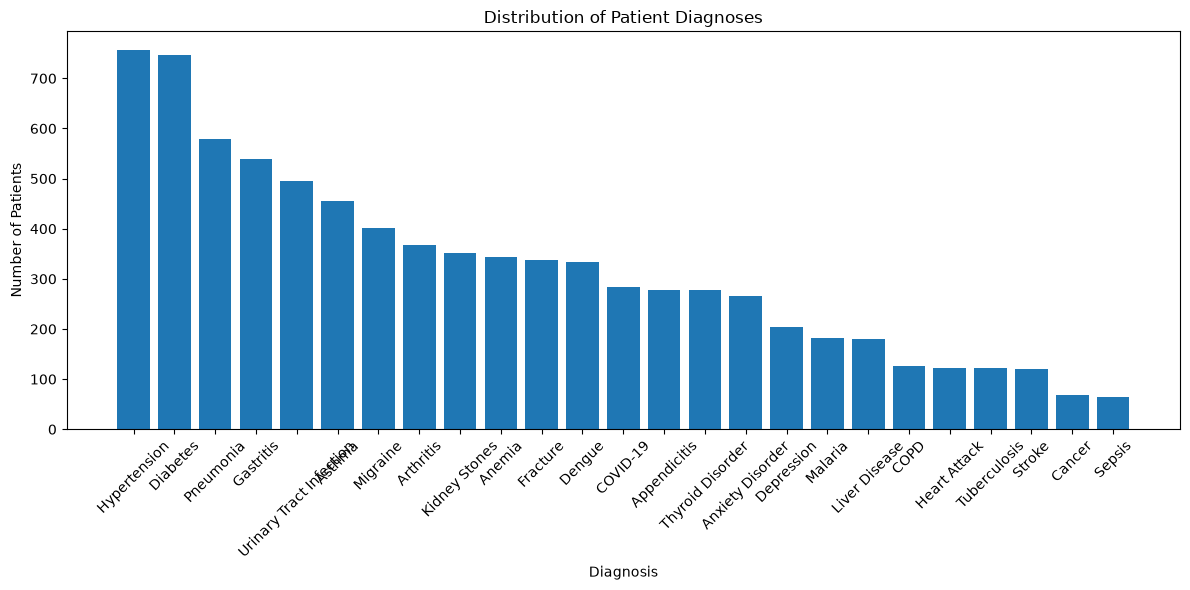

In [11]:
# Q1: Distribution of Patient Diagnoses

diagnosis_counts = df['Diagnosis'].value_counts()

plt.figure(figsize=(12,6))
plt.bar(diagnosis_counts.index, diagnosis_counts.values)

plt.title("Distribution of Patient Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The chart shows the frequency of each diagnosis among admitted patients. The most common diagnosis indicates the primary health condition treated by the hospital, while less frequent diagnoses represent comparatively rare cases. This information helps hospital management allocate medical staff and resources efficiently.

Q2. Which are the Top 10 doctors by number of patients treated?

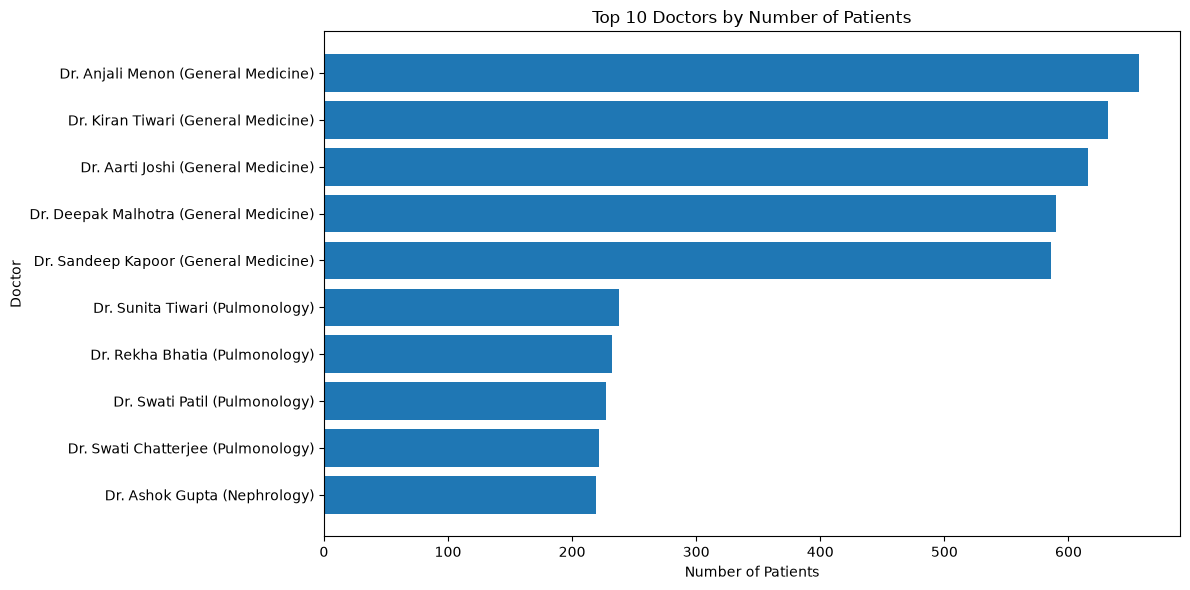

In [12]:
# Q2: Top 10 Doctors by Number of Patients

top_doctors = df['Doctor_Name'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.barh(top_doctors.index, top_doctors.values)

plt.title("Top 10 Doctors by Number of Patients")
plt.xlabel("Number of Patients")
plt.ylabel("Doctor")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The visualization highlights the doctors who treated the highest number of patients. High patient volume may indicate greater demand for specific specialties and can help management evaluate workload distribution across medical staff.

Q3. Which medical tests were performed most frequently?

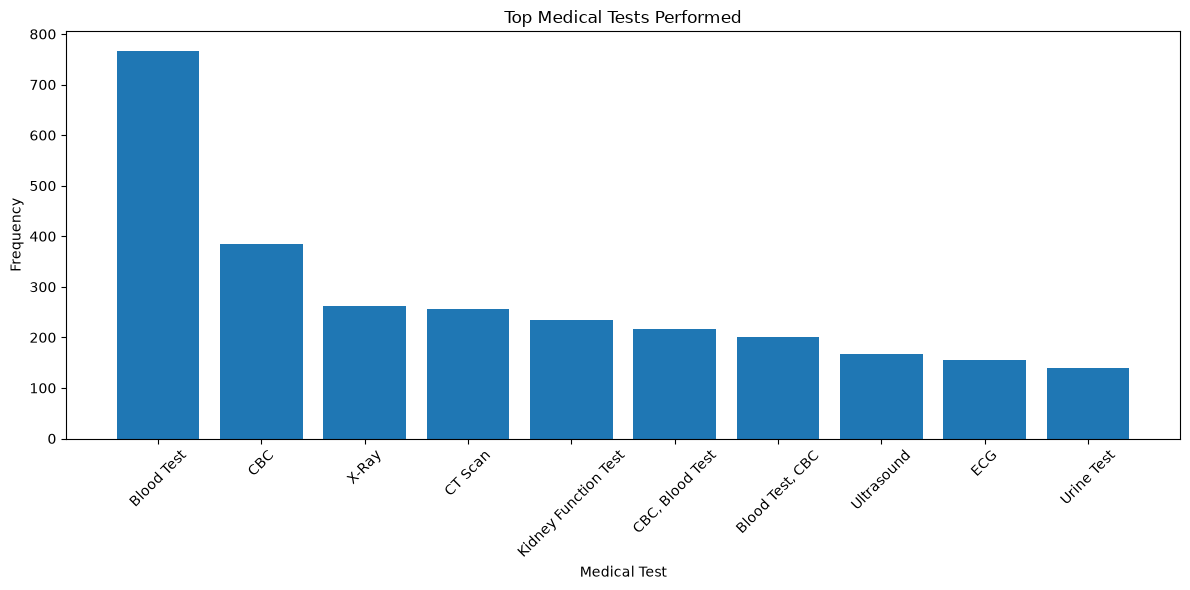

In [13]:
# Q3: Most Frequently Performed Medical Tests

test_counts = df['Test'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(test_counts.index, test_counts.values)

plt.title("Top Medical Tests Performed")
plt.xlabel("Medical Test")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Frequently performed tests indicate the hospital's most commonly used diagnostic services. This information is useful for inventory planning, laboratory resource management, and equipment utilization.

Q4. What is the distribution of bed occupancy types?

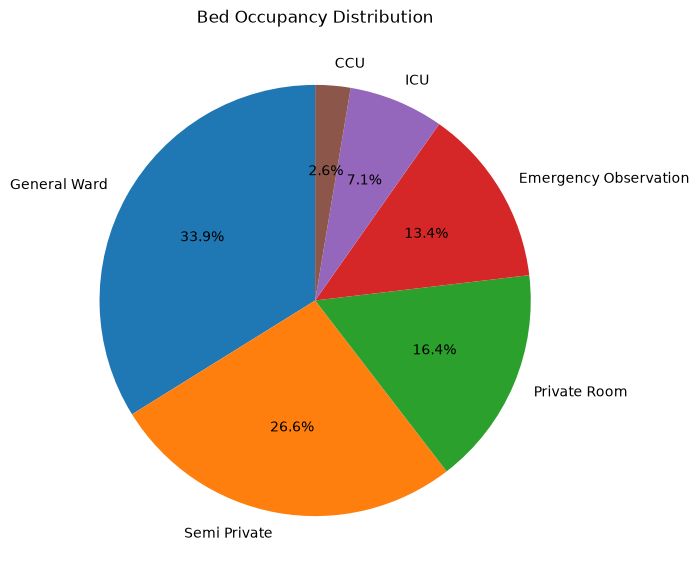

In [14]:
# Q4: Bed Occupancy Distribution

bed_counts = df['Bed_Occupancy'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    bed_counts.values,
    labels=bed_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Bed Occupancy Distribution")

plt.show()

The distribution of bed occupancy shows the proportion of patients admitted to different room categories. Understanding occupancy patterns helps optimize hospital infrastructure, bed allocation, and capacity planning.

Q5. What is the distribution of patient feedback ratings?

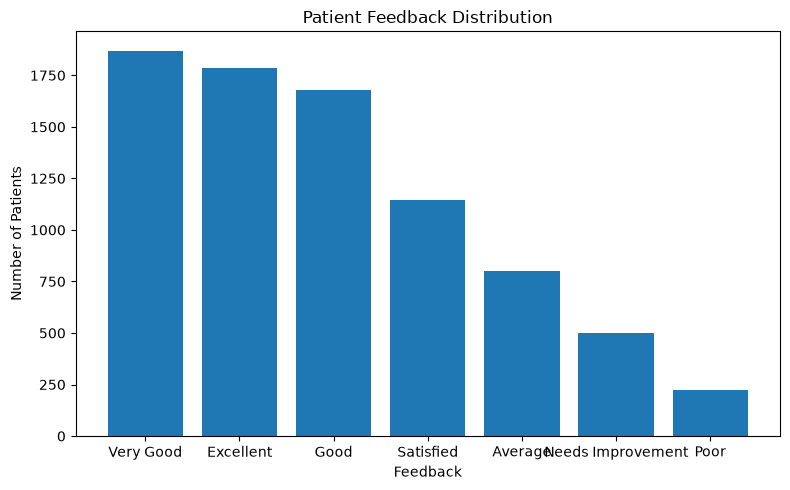

In [15]:
# Q5: Patient Feedback Distribution

feedback_counts = df['Feedback'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(feedback_counts.index, feedback_counts.values)

plt.title("Patient Feedback Distribution")
plt.xlabel("Feedback")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.show()

Patient feedback provides an overview of service quality and patient satisfaction. A higher number of positive ratings indicates strong healthcare performance, while negative feedback highlights areas requiring operational improvements

Q6. What is the distribution of billing amounts?

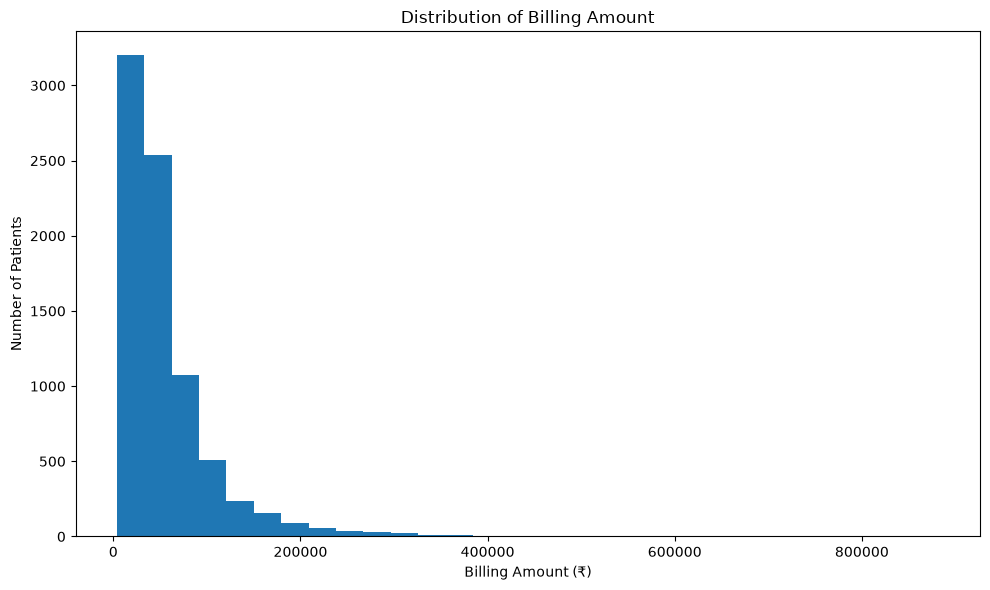

In [16]:
# Q6: Distribution of Billing Amount

plt.figure(figsize=(10,6))

plt.hist(df['Billing_Amount'], bins=30)

plt.title("Distribution of Billing Amount")
plt.xlabel("Billing Amount (₹)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

The histogram illustrates how hospital billing amounts are distributed among patients. It helps identify the typical billing range and detect unusually high or low billing values that may require further investigation

Q7. Which diagnoses generated the highest revenue?

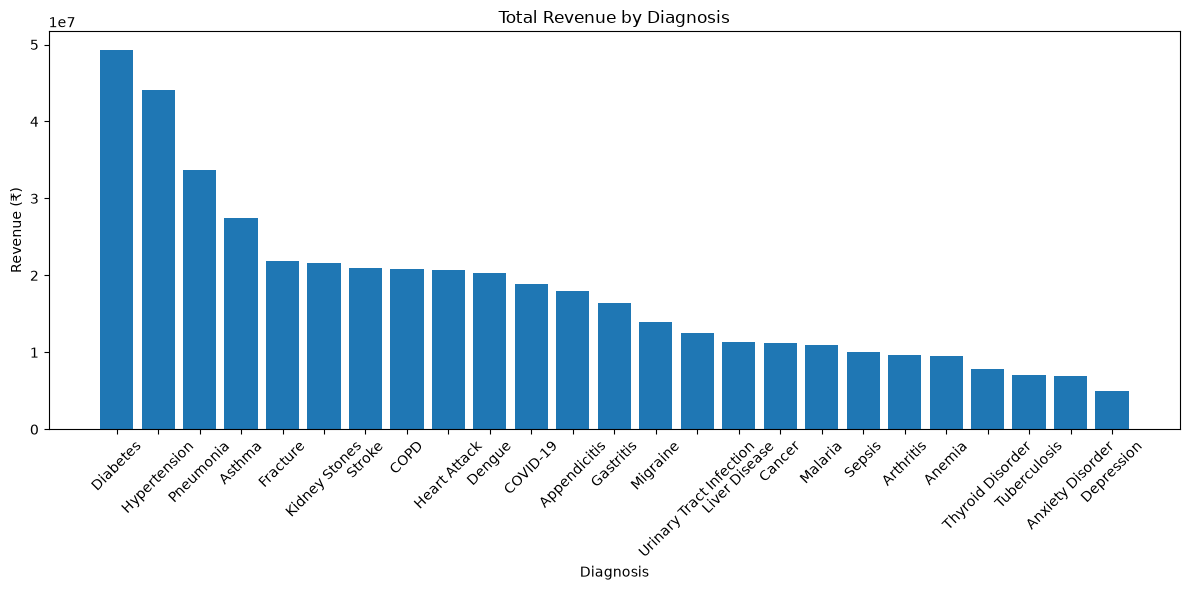

In [17]:
# Q7: Revenue by Diagnosis

revenue_by_diagnosis = (
    df.groupby('Diagnosis')['Billing_Amount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(revenue_by_diagnosis.index,
        revenue_by_diagnosis.values)

plt.title("Total Revenue by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This chart identifies which diagnoses contribute the most to hospital revenue. These conditions often require more extensive treatment and resource utilization, making them financially significant for hospital operations.

Q8. Which doctors generated the highest revenue?


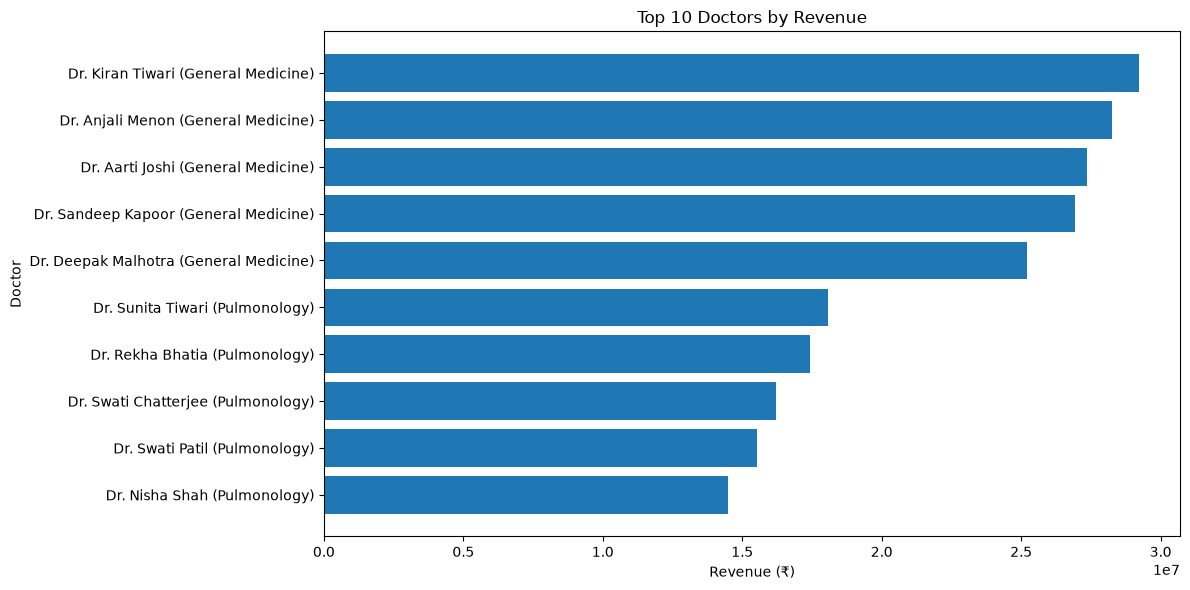

In [18]:
# Q8: Top 10 Doctors by Revenue

doctor_revenue = (
    df.groupby('Doctor_Name')['Billing_Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(doctor_revenue.index,
         doctor_revenue.values)

plt.title("Top 10 Doctors by Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Doctor")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The visualization ranks doctors based on the total revenue generated from patient treatments. This can help evaluate departmental performance and identify high-demand specialists.

Q9. What is the relationship between billing amount and insurance amount?

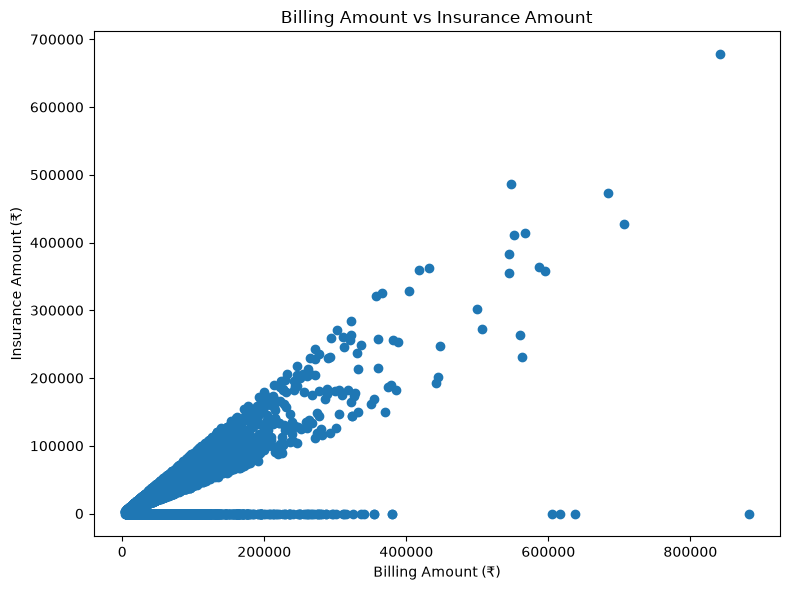

In [19]:
# Q9: Billing Amount vs Insurance Amount

plt.figure(figsize=(8,6))

plt.scatter(
    df['Billing_Amount'],
    df['Health_Insurance_Amount']
)

plt.title("Billing Amount vs Insurance Amount")
plt.xlabel("Billing Amount (₹)")
plt.ylabel("Insurance Amount (₹)")

plt.tight_layout()
plt.show()

The scatter plot shows the relationship between hospital billing and insurance coverage. A positive trend suggests that higher treatment costs are generally associated with higher insurance reimbursements.

Q10. What is the monthly trend of patient admissions?

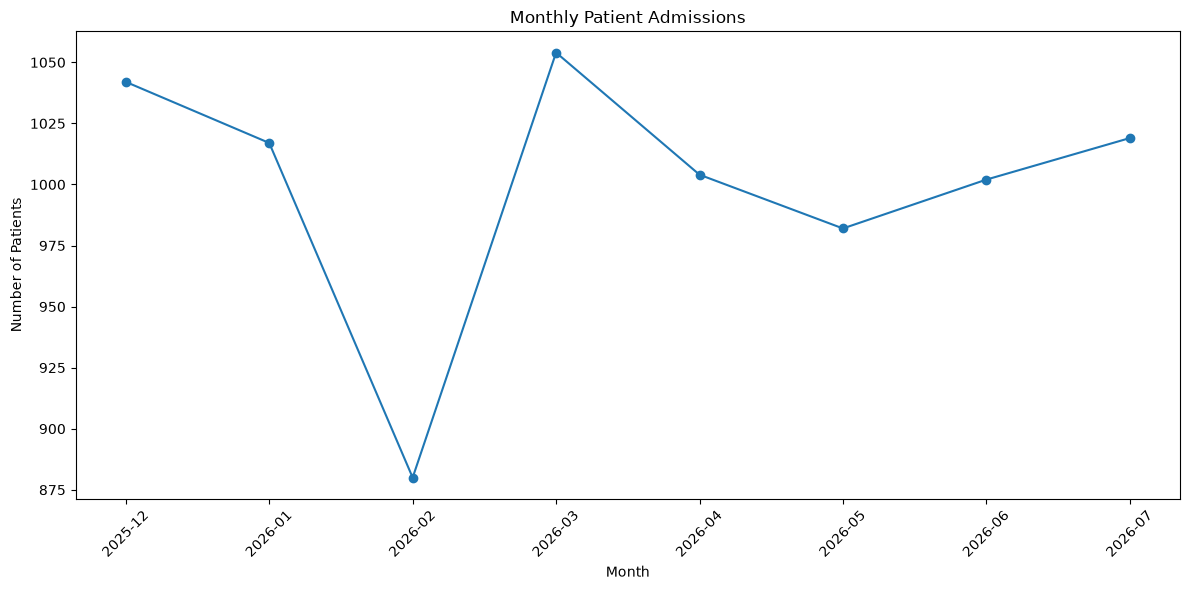

In [20]:
# Q10: Monthly Patient Admissions

monthly_admissions = (
    df.groupby(df['Admit_Date'].dt.to_period('M'))
      .size()
)

monthly_admissions.index = monthly_admissions.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values,
    marker='o'
)

plt.title("Monthly Patient Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This trend illustrates how patient admissions change over time. Seasonal peaks or declines can help hospital administrators forecast staffing requirements, bed occupancy, and resource planning.

Q11. What is the monthly hospital revenue trend?

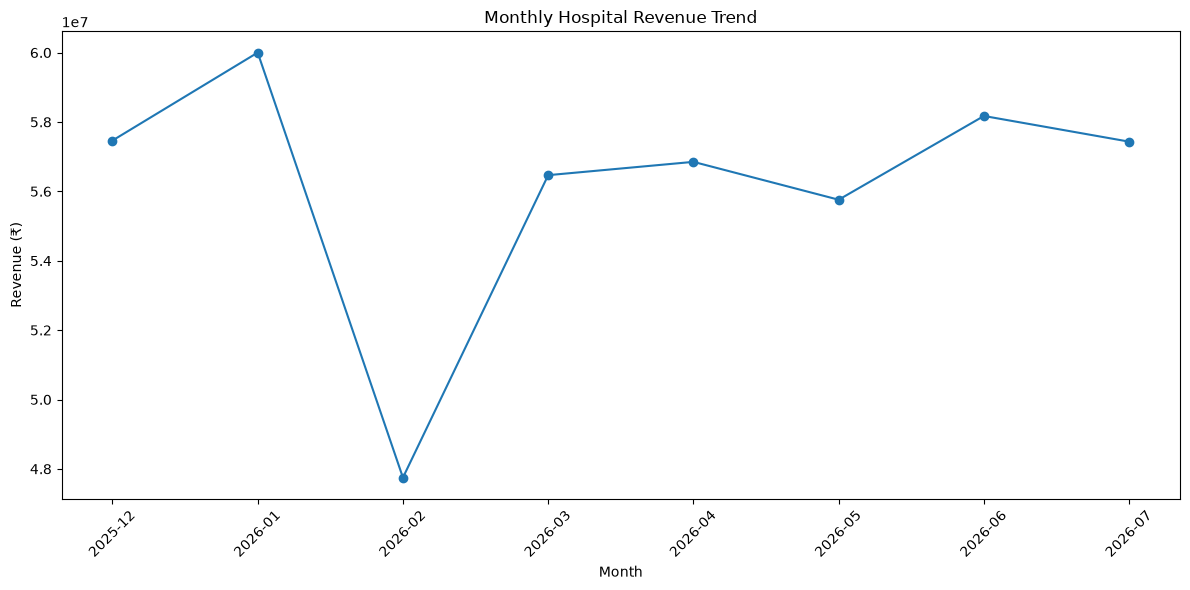

In [21]:
# Q11: Monthly Hospital Revenue Trend

monthly_revenue = (
    df.groupby(df['Admit_Date'].dt.to_period('M'))['Billing_Amount']
      .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o'
)

plt.title("Monthly Hospital Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The monthly revenue trend highlights fluctuations in hospital income over time. Identifying high and low revenue months helps management evaluate seasonal demand and improve financial planning.

Q12. What is the monthly insurance claim trend?

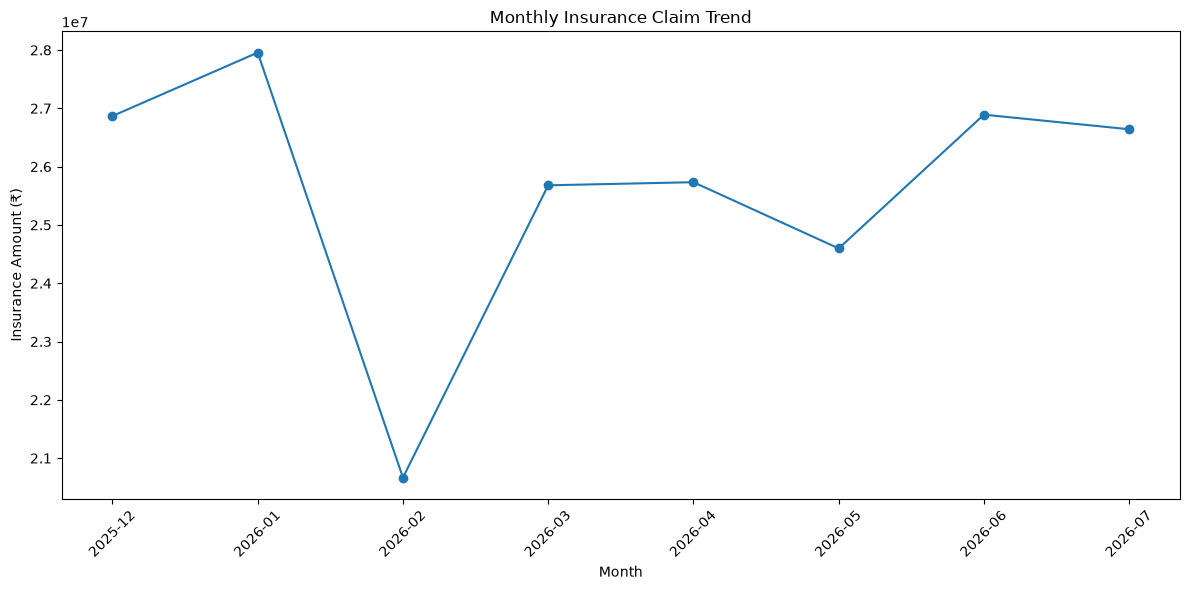

In [22]:
# Q12: Monthly Insurance Claim Trend

monthly_insurance = (
    df.groupby(df['Admit_Date'].dt.to_period('M'))['Health_Insurance_Amount']
      .sum()
)

monthly_insurance.index = monthly_insurance.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_insurance.index,
    monthly_insurance.values,
    marker='o'
)

plt.title("Monthly Insurance Claim Trend")
plt.xlabel("Month")
plt.ylabel("Insurance Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This visualization shows how insurance claims vary over time. It helps assess the hospital's dependence on insurance reimbursements and identify months with increased claim activity.

Q13. What is the distribution of patient length of stay?

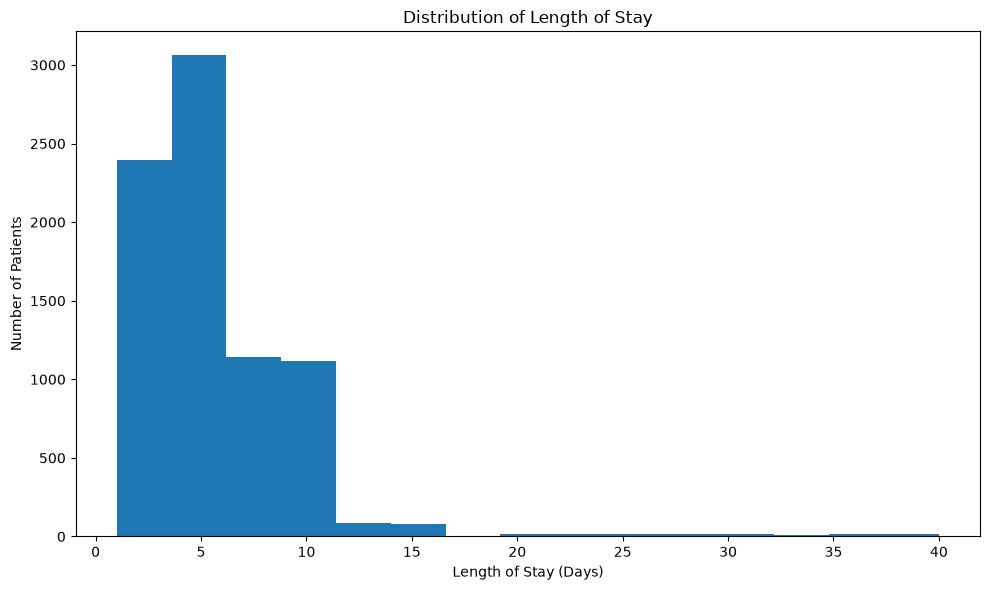

In [23]:
# Q13: Length of Stay Distribution

plt.figure(figsize=(10,6))

plt.hist(df['Length_of_Stay'], bins=15)

plt.title("Distribution of Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

The distribution of patient stay durations provides insights into hospital efficiency. Most patients with shorter stays may indicate effective treatment, while longer stays can reflect complex medical conditions.

Q14. Which patients had the highest billing amounts?

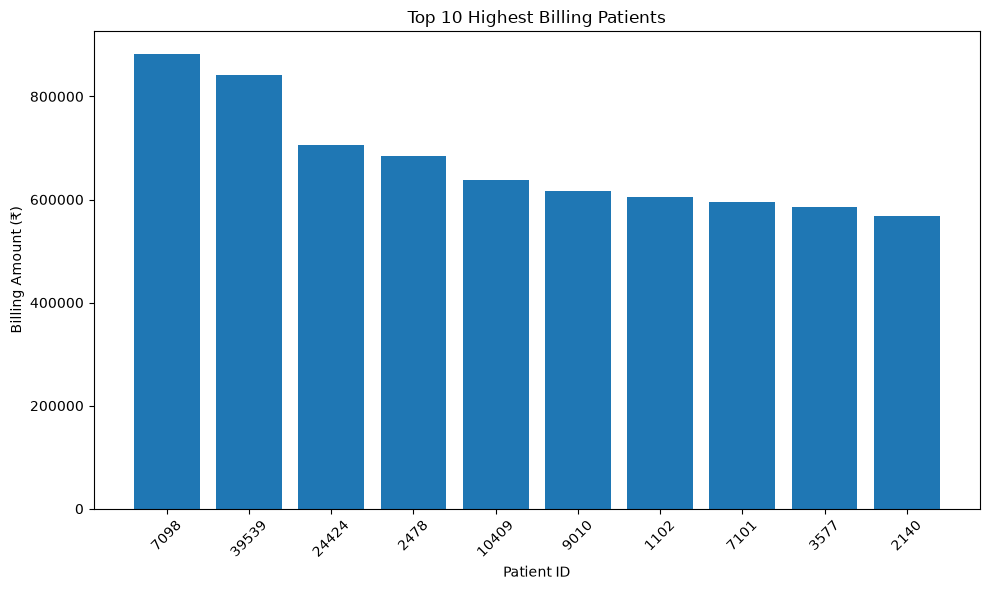

In [24]:
# Q14: Top 10 Highest Billing Patients

top_patients = (
    df[['Patient_ID', 'Billing_Amount']]
      .sort_values(by='Billing_Amount', ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    top_patients['Patient_ID'].astype(str),
    top_patients['Billing_Amount']
)

plt.title("Top 10 Highest Billing Patients")
plt.xlabel("Patient ID")
plt.ylabel("Billing Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The chart identifies patients with the highest treatment costs. These cases often involve specialized procedures, longer hospital stays, or intensive medical care, making them important for financial analysis.

Q15. Which diagnoses have the longest average hospital stay?

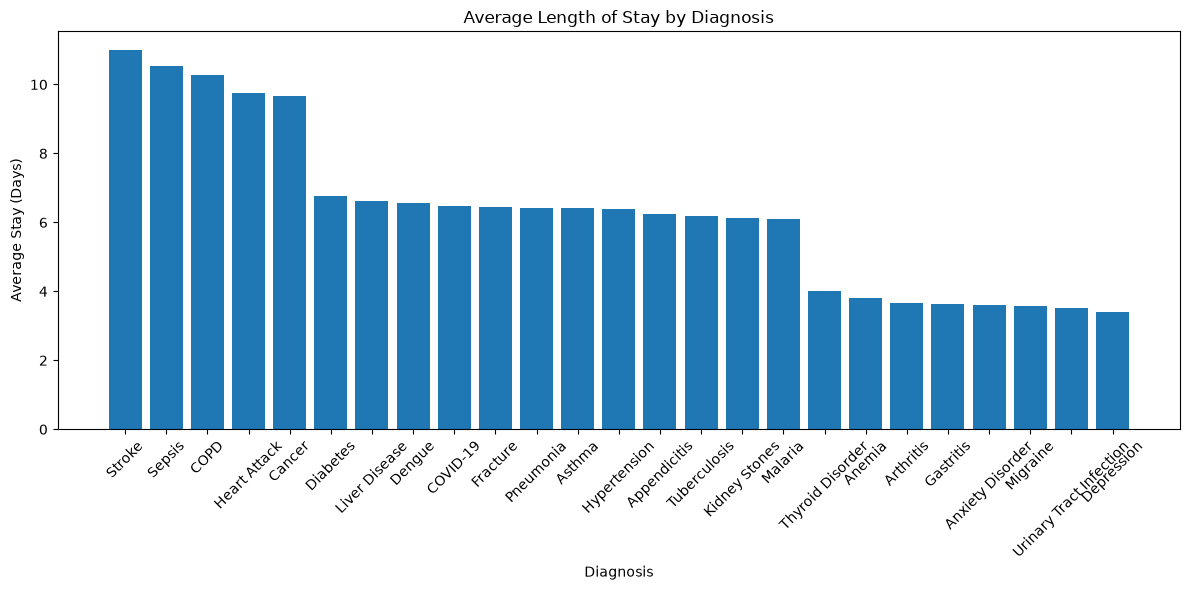

In [25]:
# Q15: Average Length of Stay by Diagnosis

avg_stay = (
    df.groupby('Diagnosis')['Length_of_Stay']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(avg_stay.index, avg_stay.values)

plt.title("Average Length of Stay by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Average Stay (Days)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This analysis identifies diagnoses associated with longer hospital stays. Understanding these conditions helps improve bed management, treatment planning, and resource allocation for patients requiring extended care.

Q16. Is there a correlation between Billing Amount, Insurance Amount, Patient Payment, and Length of Stay?

In [27]:
# Q16: Correlation Analysis

correlation = df[
    ['Billing_Amount',
     'Health_Insurance_Amount',
     'Total_Amount_Payable',
     'Length_of_Stay']
].corr()

print(correlation)

                         Billing_Amount  Health_Insurance_Amount  \
Billing_Amount                 1.000000                 0.724912   
Health_Insurance_Amount        0.724912                 1.000000   
Total_Amount_Payable           0.768182                 0.115848   
Length_of_Stay                 0.764030                 0.556691   

                         Total_Amount_Payable  Length_of_Stay  
Billing_Amount                       0.768182        0.764030  
Health_Insurance_Amount              0.115848        0.556691  
Total_Amount_Payable                 1.000000        0.584278  
Length_of_Stay                       0.584278        1.000000  


The correlation matrix measures the relationship between numerical variables. A higher positive correlation indicates that two variables tend to increase together, while a negative correlation indicates an inverse relationship. This analysis helps identify key financial and operational factors influencing hospital performance.

Q17. Executive KPI Summary

In [28]:
# Q17: Executive KPI Summary

total_patients = df['Patient_ID'].nunique()
total_revenue = df['Billing_Amount'].sum()
total_insurance = df['Health_Insurance_Amount'].sum()
total_patient_payment = df['Total_Amount_Payable'].sum()
average_bill = df['Billing_Amount'].mean()
average_stay = df['Length_of_Stay'].mean()
total_doctors = df['Doctor_Name'].nunique()
total_diagnosis = df['Diagnosis'].nunique()

print("="*50)
print("      LifeLine Hospital Executive KPI Summary")
print("="*50)

print(f"Total Patients           : {total_patients:,}")
print(f"Total Revenue            : ₹{total_revenue:,.2f}")
print(f"Total Insurance Amount   : ₹{total_insurance:,.2f}")
print(f"Total Patient Payment    : ₹{total_patient_payment:,.2f}")
print(f"Average Billing Amount   : ₹{average_bill:,.2f}")
print(f"Average Length of Stay   : {average_stay:.2f} Days")
print(f"Total Doctors            : {total_doctors}")
print(f"Total Diagnoses          : {total_diagnosis}")

print("="*50)

      LifeLine Hospital Executive KPI Summary
Total Patients           : 8,000
Total Revenue            : ₹449,895,360.00
Total Insurance Amount   : ₹205,031,480.00
Total Patient Payment    : ₹244,863,880.00
Average Billing Amount   : ₹56,236.92
Average Length of Stay   : 5.67 Days
Total Doctors            : 45
Total Diagnoses          : 25


The Executive KPI Summary provides a concise overview of the hospital's operational and financial performance. It highlights patient volume, revenue, insurance contribution, patient payments, average billing, average hospital stay, and the diversity of doctors and diagnoses. This type of summary is commonly presented to hospital management for strategic decision-making.